# Kagome band structure along Γ–K–M–Γ

Extract and plot three COMSOL bands from each CSV file listed below.

In [28]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
from defs import generate_k_space_sweep, visualize_sweep, rotate_points
from extract_kagome_bands import extract_band_frequencies

In [37]:
data_dir = '../../../data/simulation/'
out_dir = '../../../output/paper_upload/'

# Add or remove CSV filenames here to select the datasets to plot.
band_filenames = [
    'kagome_bands.csv',
    'kagome_bands_hardbound.csv',
    'kagome_bands_new_density.csv',
]

## Extract the COMSOL bands

In [38]:
band_data = {}

for filename in band_filenames:
    b_values, bands = extract_band_frequencies(data_dir + filename)
    band_data[filename] = {
        'b': np.asarray(b_values),
        'bands': np.asarray(bands),
    }
    print(f'{filename}: loaded {len(bands)} bands at {len(b_values)} b values')

kagome_bands.csv: loaded 3 bands at 48 b values
kagome_bands_hardbound.csv: loaded 3 bands at 48 b values
kagome_bands_new_density.csv: loaded 3 bands at 48 b values


## Calculate the flat-band bandwidth

In [39]:
flat_bandwidths_hz = {}

for filename, dataset in band_data.items():
    flat_band = dataset['bands'][-1]
    min_frequency = np.min(flat_band)
    max_frequency = np.max(flat_band)
    bandwidth = max_frequency - min_frequency
    flat_bandwidths_hz[filename] = bandwidth
    print(
        f'{filename}: flat-band bandwidth = {bandwidth:.6g} Hz '
        f'({max_frequency:.6g} - {min_frequency:.6g} Hz)'
    )

kagome_bands.csv: flat-band bandwidth = 308.943 Hz (14624.9 - 14316 Hz)
kagome_bands_hardbound.csv: flat-band bandwidth = 301.677 Hz (14582.4 - 14280.7 Hz)
kagome_bands_new_density.csv: flat-band bandwidth = 303.994 Hz (14601.6 - 14297.6 Hz)


## Plot the Γ–K–M–Γ band structure

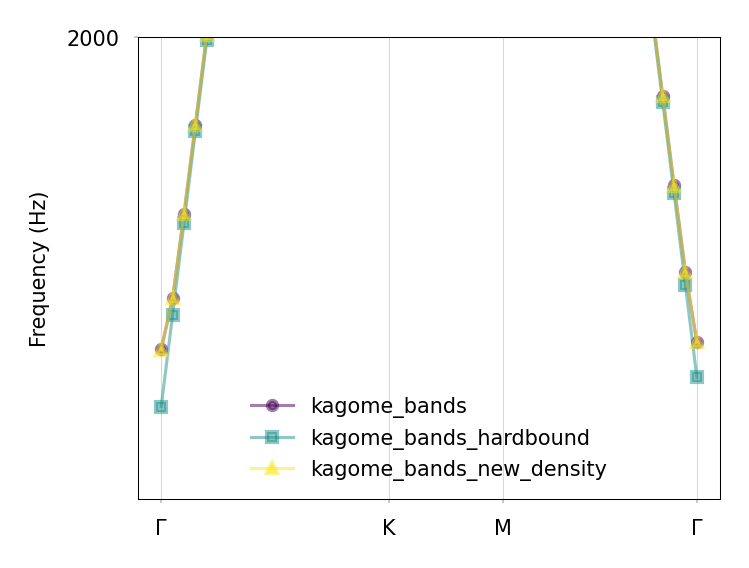

In [54]:
rcParams.update({
    'font.size': 5,
    'axes.labelsize': 5,
    'xtick.labelsize': 5,
    'ytick.labelsize': 5,
})

fig, ax = plt.subplots(figsize=(2.5, 2), dpi=300)

b_max = max(dataset['b'][-1] for dataset in band_data.values())
ax.set_xlim(-0.1, b_max+0.1)
ax.set_ylim(-500, 15500)
ax.set_ylabel('Frequency (Hz)')
ax.set_xticks([0, 1, 1.5, b_max], ['Γ', 'K', 'M', 'Γ'])
ax.set_yticks(np.linspace(2000, 14000, 4, endpoint=True))
ax.xaxis.set_tick_params(width=0.1, length=1)
ax.yaxis.set_tick_params(width=0.1, length=1)

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(0.25)

colors = plt.cm.viridis(np.linspace(0, 1, len(band_data)))
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']
for dataset_index, (color, (filename, dataset)) in enumerate(
    zip(colors, band_data.items())
):
    marker = markers[dataset_index]
    for band_index, band in enumerate(dataset['bands']):
        ax.plot(
            dataset['b'], band, color=color, linewidth=0.75, alpha=0.5,
            marker=marker, markersize=2.2, markevery=1,
            label=filename.removesuffix('.csv') if band_index == 0 else None,
        )

ax.legend(loc='lower center', frameon=False)
ax.grid(linewidth=0.25, alpha=0.5)
ax.set_ylim(-500, 2000)
plt.show()

## Calculate residuals relative to the hardbound bands

The signed residual is defined as `other dataset − hardbound reference` in Hz.

In [55]:
reference_filename = 'kagome_bands_hardbound.csv'
if reference_filename not in band_data:
    raise KeyError(f'{reference_filename} must be included in band_filenames')

reference = band_data[reference_filename]
band_residuals_hz = {}
residual_statistics_hz = {}

for filename, dataset in band_data.items():
    if filename == reference_filename:
        continue

    reference_bands = np.asarray([
        np.interp(dataset['b'], reference['b'], reference_band)
        for reference_band in reference['bands']
    ])
    residuals = dataset['bands'] - reference_bands
    band_residuals_hz[filename] = residuals

    rmse_by_band = np.sqrt(np.mean(residuals**2, axis=1))
    max_abs_by_band = np.max(np.abs(residuals), axis=1)
    residual_statistics_hz[filename] = {
        'rmse_by_band': rmse_by_band,
        'max_abs_by_band': max_abs_by_band,
    }

    print(f'\n{filename} - {reference_filename}')
    for band_index, (rmse, max_abs) in enumerate(
        zip(rmse_by_band, max_abs_by_band), start=1
    ):
        print(
            f'  Band {band_index}: RMSE = {rmse:.6g} Hz, '
            f'max |residual| = {max_abs:.6g} Hz'
        )


kagome_bands.csv - kagome_bands_hardbound.csv
  Band 1: RMSE = 55.5629 Hz, max |residual| = 309.108 Hz
  Band 2: RMSE = 42.294 Hz, max |residual| = 189.747 Hz
  Band 3: RMSE = 39.5223 Hz, max |residual| = 42.5682 Hz

kagome_bands_new_density.csv - kagome_bands_hardbound.csv
  Band 1: RMSE = 50.036 Hz, max |residual| = 308.877 Hz
  Band 2: RMSE = 34.5782 Hz, max |residual| = 189.461 Hz
  Band 3: RMSE = 18.3596 Hz, max |residual| = 19.265 Hz


## Plot residuals versus b

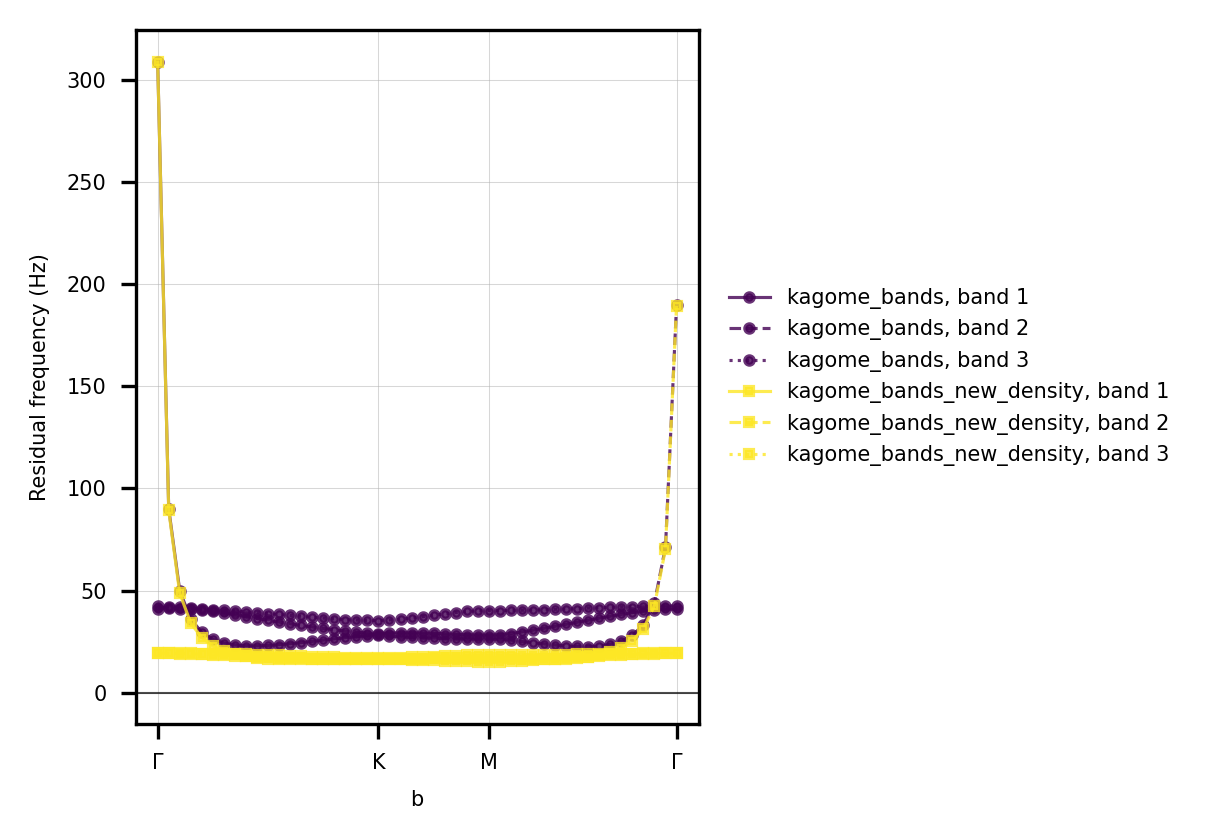

In [63]:
residual_filenames = list(band_residuals_hz)
if not residual_filenames:
    raise ValueError('No non-reference datasets are available to plot')

fig, ax = plt.subplots(figsize=(4, 2.75), dpi=300)
residual_colors = plt.cm.viridis(
    np.linspace(0, 1, len(residual_filenames))
)
residual_markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']
band_linestyles = ['-', '--', ':']

for file_index, (filename, color) in enumerate(
    zip(residual_filenames, residual_colors)
):
    b_values = band_data[filename]['b']
    marker = residual_markers[file_index % len(residual_markers)]
    for band_index, residual in enumerate(band_residuals_hz[filename]):
        ax.plot(
            b_values, residual, color=color,
            linestyle=band_linestyles[band_index], linewidth=0.75,
            marker=marker, markersize=2, alpha=0.8,
            label=(
                f"{filename.removesuffix('.csv')}, band {band_index + 1}"
            ),
        )

b_max = max(band_data[name]['b'][-1] for name in residual_filenames)
ax.axhline(0, color='black', linewidth=0.5, alpha=0.7)
ax.set_xlim(-0.1, b_max+0.1)
ax.set_xticks([0, 1, 1.5, b_max], ['Γ', 'K', 'M', 'Γ'])
ax.set_xlabel('b')
ax.set_ylabel('Residual frequency (Hz)')
ax.grid(linewidth=0.25, alpha=0.5)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout()
plt.show()